# Congressional Bills Data Cleaning

This notebook creates the `*.csv` data files included in this repo. The code is based on the [replication code](https://osf.io/gjt87/) from Egami et al. (2023).

In [1]:
import os
import pandas as pd
import numpy as np

# Define directories
repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
os.chdir(repo_dir)

data_dir = os.path.join(repo_dir, "01_bills")
os.makedirs(data_dir, exist_ok=True)

## Load data from CAP

In [2]:
cap_path = os.path.join(data_dir, "US-Legislative-congressional_bills_19.3_3_3.csv")
if os.path.isfile(cap_path)!=True:
    cap_path = "https://comparativeagendas.s3.amazonaws.com/datasetfiles/US-Legislative-congressional_bills_19.3_3_3.csv"
cap = pd.read_csv(cap_path, low_memory=False)
print(f"Downloaded CAP data, n = {len(cap)}")

# Correct bill IDs
cap["BillID_corrected"] = cap["cong"].astype(str) + "-" + cap["bill_type"].apply(lambda x: x.upper()) + "-" + cap["bill_no"].astype(str) 
cap_wrong_bill_id = cap[cap["bill_id"] != cap["BillID_corrected"]]
print(f"Corrected bill_id of {len(cap_wrong_bill_id)} observations")

# Remove duplicates based on bill ID
# cap_dup = cap[cap["BillID_corrected"].duplicated(keep=False)]
n_pre = len(cap)
cap.drop_duplicates(subset=["BillID_corrected"], inplace=True)
print(f"Dropped {n_pre - len(cap)} duplicates, n = {len(cap)}")

Downloaded CAP data, n = 468437
Corrected bill_id of 13361 observations
Dropped 4 duplicates, n = 468433


In [3]:
if ~((cap.loc[cap["cong"]==114,"chamber"].unique()) == [1,2]).all():
    print("Incorrect chamber encoding for cong=114")
    cap.loc[cap["cong"]==114,"chamber"] = cap.loc[cap["cong"]==114,"chamber"] + 1

cap.loc[(cap["party"]==400) & (cap["name_full"]=="Anibal Acevedo-Vila"), "party"] = 100 # recode as Democratic (100)

Incorrect chamber encoding for cong=114


In [4]:
# Drop unnecessary columns
n_pre = len(cap.columns)
cap.drop(columns=[
        "id", "bill_id", "cong", "bill_type",  "bill_no", "name_full", "chamber",
        "intr_date", "intr_month", "pap_majortopic", "pap_subtopic", "subtopic",
        "filter_plaw", "plaw_date", "plaw_no", "majority", "comment"
    ], inplace=True)
print(f"Dropped {n_pre - len(cap.columns)} columns")

# Rename columns for consistency
cap.rename(columns={
    'majortopic': 'Major',
    'description': 'Description',
    'year': 'Year',
    'party': 'Party', 
    'pass_h': 'PassH', 
    'pass_s': 'PassS'}, inplace=True)

Dropped 17 columns


In [5]:
major_text_pap = {
    1 : "Macroeconomics",
    2 : "Civil Rights, Minority Issues, and Civil Liberties",
    3 : "Health",
    4 : "Agriculture",
    5 : "Labor and Employment",
    6 : "Education",
    7 : "Environment",
    8 : "Energy",
    9 : "Immigration",
    10: "Transportation",
    12: "Law, Crime, and Family Issues",
    13: "Social Welfare",
    14: "Community Development and Housing Issues",
    15: "Banking, Finance, and Domestic Commerce",
    16: "Defense",
    17: "Space, Science, Technology, and Communications",
    18: "Foreign Trade",
    19: "International Affairs and Foreign Aid",
    20: "Government Operations",
    21: "Public Lands and Water Management",
    23: "Arts and Entertainment",
    99: "Other, Miscellaneous, and Human Interest"
}
# Add MajorText column 
cap["MajorText"] = cap["Major"].apply(lambda x: major_text_pap[x] if pd.notnull(x) else x)

In [6]:
# Rearrange columns
cap = cap[['BillID_corrected', 'Year', 'Major', 'MajorText', 'Description', 'Party', 'PassH', 'PassS']]

# Display the first few rows of CAP data
cap.head()

,BillID_corrected,Year,Major,MajorText,Description,Party,PassH,PassS
0,80-S-1873,1947,1.0,Macroeconomics,"A bill to maintain prosperity, promote full em...",200.0,0.0,0.0
1,80-HR-3000,1947,1.0,Macroeconomics,To amend the Employment Act of1946 so as to pr...,200.0,0.0,0.0
2,80-HR-4743,1947,1.0,Macroeconomics,"To maintain prosperity, to promote full employ...",200.0,0.0,0.0
3,80-S-525,1947,1.0,Macroeconomics,A bill to promote the progress of science and ...,100.0,0.0,0.0
4,80-HR-1815,1947,1.0,Macroeconomics,To promote the progress of science; to advance...,200.0,0.0,0.0


## Load variables from CBP

In [7]:
cbp_80_92_path = os.path.join(data_dir, "bills80-92.txt")
if os.path.isfile(cbp_80_92_path)!=True:
    cbp_80_92_path = "http://congressionalbills.org/billfiles/bills80-92.zip"
cbp_80_92 = pd.read_csv(cbp_80_92_path, sep='\t', encoding='latin-1', low_memory=False)
cbp_80_92.rename(columns={' ': 'Minor'}, inplace=True)
cbp_80_92.drop(columns=['id', 'ByReq', 'Commem', 'oldMajor', 'oldMinor', 'Month',  'ReferArr', 'Year', 'Age', 'ComMArr', 'DW2', 'LeadCham', 'LeadComm', 'LeadSubC'], inplace=True)
cbp_80_92["DW1"] = cbp_80_92["DW1"].apply(lambda x: np.nan if x == -99.0 else x)

cbp_93_114_path = os.path.join(data_dir, "bills93-114.csv")
if os.path.isfile(cbp_93_114_path)!=True:
    cbp_93_114_path = "http://congressionalbills.org/billfiles/bills93-114.zip"
cbp_93_114 = pd.read_csv(cbp_93_114_path, sep=';', encoding='latin-1', low_memory=False)
cbp_93_114.drop(columns='ImpBill', inplace=True)
# cbp_93_114 = cbp_93_114[cbp_80_92.columns.to_list()] # align columns, not needed but personal preference
cbp_93_114["DW1"] = cbp_93_114["DW1"].apply(lambda s: float(s.replace(",", ".") if isinstance(s, str) else s))

# Combine CBP datasets
cbp = pd.concat([cbp_80_92, cbp_93_114]).reset_index()
cbp.drop(columns='index', inplace=True)
print(f"Loaded CBP data, n={len(cbp)}")

Loaded CBP data, n=523841


In [8]:
# Correct BillID
cbp["BillType"] = cbp["BillType"].apply(lambda x: x.upper())
cbp["BillID_corrected"] = cbp["Cong"].astype(str) + "-" + cbp["BillType"] + "-" + cbp["BillNum"].astype(str) 
cbp_wrong_bill_id = cbp[cbp["BillID"] != cbp["BillID_corrected"]]
print(f"Corrected bill_id of {len(cbp_wrong_bill_id)} observations")
cbp.drop(columns="BillID", inplace=True)

# Remove duplicates in CBP based on BillID + choose the version with Major code similar to CAP
# If we decided to go with CBP data only, this needs to be updated
def remove_cbp_dup(cbp, cap):
    cbp_dup = cbp[cbp["BillID_corrected"].duplicated(keep=False)]
    for bill_id in cbp_dup["BillID_corrected"].unique():
        cap_major = cap.loc[cap["BillID_corrected"]==bill_id, "Major"].item()
        condition = (cbp["BillID_corrected"]==bill_id) & (cbp["Major"]!=cap_major)
        cbp = cbp[~condition]
        print(f"Dropped {condition.sum()} duplicates of {bill_id} with major topic that is inconsistent with that in CAP, {cap_major}")
    return(cbp)
    
# cbp_dup = cbp[cbp["BillID_corrected"].duplicated(keep=False)]
cbp = remove_cbp_dup(cbp, cap[["BillID_corrected", "Major"]])

# If both match, then keep the first even though they vary in other variables
n_pre = len(cbp)
cbp.drop_duplicates(subset=["BillID_corrected", "Major", "Minor"], inplace=True)
print(f"Dropped {n_pre - len(cbp)} duplicates based on bill_id, keeping first one if they vary in more than one variable, n = {len(cbp)}")

Corrected bill_id of 1 observations
Dropped 2 duplicates of 107-HR-5715 with major topic that is inconsistent with that in CAP, 12.0
Dropped 1 duplicates of 107-S-3051 with major topic that is inconsistent with that in CAP, 9.0
Dropped 1 duplicates of 107-S-3160 with major topic that is inconsistent with that in CAP, 15.0
Dropped 1 duplicates based on bill_id, keeping first one if they vary in more than one variable, n = 523836


In [9]:
# Add MajorText column 
cbp["MajorText"] = cbp["Major"].apply(lambda x: major_text_pap[x] if pd.notnull(x) else x)

In [10]:
# Impute missing DW1 scores
cbp["DW1_impute"] = cbp["DW1"]
cbp.fillna(value={"DW1_impute": cbp["DW1"].mean()}, inplace=True)
print(f"Impute the {np.isnan(cbp['DW1']).sum()} missing DW1 scores using the mean, {cbp['DW1'].mean()}")

Impute the 7161 missing DW1 scores using the mean, -0.07263037915904587


In [11]:
# Rename columns
cbp.rename(columns={'Title': 'Description'}, inplace=True)

# Rearrange columns
col_first = ['BillID_corrected', 'Major', 'MajorText', 'Description', 'Party', 'PassH', 'PassS', 'DW1', 'DW1_impute']
col_remaining = [ col for col in cbp.columns if (col not in col_first) ]
cbp = cbp[col_first + col_remaining]

# Display the first few rows of CBP data
cbp.head()

,BillID_corrected,Major,MajorText,Description,Party,PassH,PassS,DW1,DW1_impute,BillNum,...,NameFull,NameLast,PooleID,Postal,State,URL,ChRef,RankRef,SubChRef,SubRankRef
0,80-HR-1,1.0,Macroeconomics,To reduce individual income tax payments,200.0,1,1,0.533,0.533,1,...,"Knutson, Harold",Knutson,5352.0,MN,33.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN
1,80-HR-2,16.0,Defense,To amend the Armed Forces Leave Act of 1946 by...,200.0,0,0,0.224,0.224,2,...,"Van Zandt, James E.",Van Zandt,9645.0,PA,14.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN
2,80-HR-3,16.0,Defense,To amend the Armed Forces Leave Act of 1946 to...,100.0,0,0,0.003,0.003,3,...,"Rogers, Dwight L.",Rogers,8023.0,FL,43.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN
3,80-HR-4,12.0,"Law, Crime, and Family Issues",To safeguard the admission of evidence in cert...,100.0,1,0,-0.125,-0.125,4,...,"Hobbs, Sam",Hobbs,4471.0,AL,41.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN
4,80-HR-5,16.0,Defense,To protect honorably discharged veterans in th...,100.0,0,0,0.226,0.226,5,...,"Rankin, John E.",Rankin,7731.0,MS,46.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN


## Merge CAP and CBP

In [12]:
# Merge CAP and CBP datasets
bills = cap.merge(cbp, left_on="BillID_corrected", right_on="BillID_corrected", suffixes=("_CAP", "_CBP"))
print(f"Merged CAP and CBP data, n = {len(bills)}")

Merged CAP and CBP data, n = 468433


In [13]:
bills["Description_CBP"] = bills["Description_CBP"].str.replace('??????', '')
bills["Description_CBP"] = bills["Description_CBP"].str.replace('???', '')
bills["Description_CAP"] = bills["Description_CAP"].str.replace('_??', '')

bills["Description_CBP"] = bills["Description_CBP"].str.replace('""""', '')
bills["Description_CAP"] = bills["Description_CAP"].str.replace('""""', '')

bills["Description_CBP"] = bills["Description_CBP"].str.replace('`', '')
bills["Description_CAP"] = bills["Description_CAP"].str.replace('`', '')

bills.loc[bills["Description_CAP"]!=bills["Description_CBP"], "Description_CBP"] = bills.loc[bills["Description_CAP"]!=bills["Description_CBP"], "Description_CBP"].str.replace('\' ', ' ')
bills.loc[bills["Description_CAP"]!=bills["Description_CBP"], "Description_CBP"] = bills.loc[bills["Description_CAP"]!=bills["Description_CBP"], "Description_CBP"].str.replace(' \'', ' ')
bills.loc[bills["Description_CAP"]!=bills["Description_CBP"], "Description_CAP"] = bills.loc[bills["Description_CAP"]!=bills["Description_CBP"], "Description_CAP"].str.replace('\' ', ' ')
bills.loc[bills["Description_CAP"]!=bills["Description_CBP"], "Description_CAP"] = bills.loc[bills["Description_CAP"]!=bills["Description_CBP"], "Description_CAP"].str.replace(' \'', ' ')

bills["Description_CAP"] = bills["Description_CAP"].str.replace("'s", "s") 
bills["Description_CBP"] = bills["Description_CBP"].str.replace("'s", "s") 

condition = (bills["Description_CAP"]!=bills["Description_CBP"]) & (bills["Description_CAP"].apply(lambda x: x[:6]=="A bill")) & (bills["Description_CBP"].apply(lambda x: x[:6]=="An Act"))
bills.loc[condition,"Description_CAP"] = bills.loc[condition,"Description_CAP"].str.replace("A bill","An Act", n=1) # around 1000 of those are different in how they start: "A bill" vs "An Act"

condition = bills["Description_CAP"]!=bills["Description_CBP"]
bills.loc[condition, "Description_CAP"] = bills.loc[condition, "Description_CAP"].str.replace("'", "")

bills_mismatch_description = bills[bills["Description_CAP"]!= bills["Description_CBP"]]
print(f"Number of bills with mismatched description in CAP and CBP = {len(bills_mismatch_description)}") 

Number of bills with mismatched description in CAP and CBP = 5449


In [14]:
# As in Egami et al. (2023), use Major_CAP rather than Major_CBP. They are not the same, but according to the supplementary materials of  Egami et al. (2023): "The bill texts and topic labels are more standardized in the CAP version" 
bills_mismatch_major = bills[bills["Major_CAP"]!=bills["Major_CBP"]]
print(f"Found {len(bills_mismatch_major)} bills with mismatching in Major_CAP and Major_CAP=99")

Found 6130 bills with mismatching in Major_CAP and Major_CAP=99


In [15]:
data_source = "CBP"
print(f"Drop bills using {data_source}...")

bills["Major"] = bills["Major_"+data_source]
bills["MajorText"] = bills["MajorText_"+data_source]
bills["Description"] = bills["Description_"+data_source]
bills["Party"] = bills["Party_"+data_source]
bills["PassH"] = bills["PassH_"+data_source]
bills["PassS"] = bills["PassS_"+data_source]

# # Major_CBP is not used following Egami et al. (2023)
# bills.drop(columns=["Major_CBP"], inplace=True) 

# Drop bills with missing data in key columns
condition = bills[["Major", "Description", "Party", "PassH", "PassS"]].isnull().any(axis=1)
bills = bills[~condition]
print(f"Dropped {condition.sum()} bills with missing data from Major, Description, Party, PassH, PassS, n = {len(bills)}")

# Remove observations with Major=99 (~80,000)
condition = bills["Major"]==99
bills = bills[~condition]
print(f"Dropped {condition.sum()} observations with Major=99, n = {len(bills)}")

Drop bills using CBP...
Dropped 5549 bills with missing data from Major, Description, Party, PassH, PassS, n = 462884
Dropped 78552 observations with Major=99, n = 384332


In [16]:
bills[bills["Major_recoded"]==1, "MajorText"]

KeyError: 'Major_recoded'

In [ ]:
# Recode major topic IDs (1,...,10,12,...,21,23) to (1,...,10,11,...,20,21)
major_pap = bills["Major"].unique()
major_pap2ours = {} 
for i in range(len(major_pap)): 
    dict_key = major_pap[i]
    dict_val = i+1
    major_pap2ours[dict_key] = dict_val
bills["Major_recoded"] = bills["Major"].astype(int).apply(lambda x: major_pap2ours[x])

major_text_ours = {}
for major in bills["Major_recoded"].unique(): 
    dict_key = major
    dict_val = bills.loc[bills["Major_recoded"]==major, "MajorText"].unique()[0]
    major_text_ours[dict_key] = dict_val
    print(f"{dict_key}: {dict_val}")
    

1: Macroeconomics
2: Civil Rights, Minority Issues, and Civil Liberties
3: Health
4: Agriculture
5: Labor and Employment
6: Education
7: Environment
8: Energy
9: Immigration
10: Transportation
11: Law, Crime, and Family Issues
12: Social Welfare
13: Community Development and Housing Issues
14: Banking, Finance, and Domestic Commerce
15: Defense
16: Space, Science, Technology, and Communications
17: Foreign Trade
18: International Affairs and Foreign Aid
19: Government Operations
20: Public Lands and Water Management
21: Arts and Entertainment


In [ ]:
# Drop columns with more than 10% missing values
n_pre = len(bills.columns)
bills.dropna(axis=1, thresh=int(len(bills) * 0.9), inplace=True)
print(f"Dropped {n_pre - len(bills.columns)} columns that contain more than 10% missing values")

# Rename columns 
bills.rename(columns={
    'BillID_corrected': 'BillID',
    'Major_recoded': 'Major'
    }, inplace=True)

# Rearrange columns
col_first = [
    'BillID', 'Year', 
    'Major', 'MajorText', 
    'Party', 'PassH', 'PassS', 'Description',
    'DW1', 'DW1_impute',
    'Description_CAP', 'Description_CBP',
    'Party_CAP', 'Party_CBP', 
    'PassH_CAP', 'PassH_CBP', 
    'PassS_CAP', 'PassS_CBP',
    ]
col_remaining = [ col for col in bills.columns if (col not in col_first) ]
bills = bills[col_first + col_remaining]

# Display the first few rows of cleaned data
bills.head()

Dropped 13 columns that contain more than 10% missing values


,BillID,Year,Major,MajorText,Party,PassH,PassS,Description,DW1,DW1_impute,...,Majority,MemberID,MRef,NameFirst,NameFull,NameLast,PooleID,Postal,State,URL
0,80-S-1873,1947,1,Macroeconomics,200.0,0,0,"A bill to maintain prosperity, promote full em...",NaN,-0.07263,...,1.0,1489-80-200,1,HOMER EARL,"Capehart, Home",CAPEHART,1489.0,IN,22.0,http://beta.congress.gov/bill/80th-congress/se...
1,80-HR-3000,1947,1,Macroeconomics,200.0,0,0,To amend the Employment Act of1946 so as to pr...,0.750,0.75000,...,1.0,4487-80-200,1,Clare E.,"Hoffman, Clare E.",Hoffman,4487.0,MI,23.0,http://beta.congress.gov/bill/80th-congress/ho...
2,80-HR-4743,1947,1,Macroeconomics,200.0,0,0,"To maintain prosperity, to promote full employ...",0.544,0.54400,...,1.0,5434-80-200,1,Gerald W.,"Landis, Gerald W.",Landis,5434.0,IN,22.0,http://beta.congress.gov/bill/80th-congress/ho...
3,80-S-525,1947,1,Macroeconomics,100.0,0,0,A bill to promote the progress of science and ...,NaN,-0.07263,...,0.0,9291-80-100,1,ELBERT DUNCAN,"Thomas, Elbert",THOMAS,9291.0,UT,67.0,http://beta.congress.gov/bill/80th-congress/se...
4,80-HR-1815,1947,1,Macroeconomics,200.0,0,0,To promote the progress of science; to advance...,0.095,0.09500,...,1.0,1569-80-200,1,Clifford P.,"Case, Clifford P.",Case,1569.0,NJ,12.0,http://beta.congress.gov/bill/80th-congress/ho...


In [ ]:
# Lowercase descriptions, unlike Egami et al. use the ones from CBP instead of CAP
bills["Description_lower"] = bills["Description"].apply(lambda x: x.lower())

# Remove duplicates based on Major and Description
col_for_dup_check = ['Major', 'Description_lower']
# bills_dup = bills[bills[col_for_dup_check].duplicated(keep=False)]

n_pre = len(bills)
bills.drop_duplicates(subset=col_for_dup_check, inplace=True)
print(f"Dropped {n_pre - len(bills)} duplicates that varied in bills_dup_col, n = {len(bills)}")

bills.drop(columns="Description_lower", inplace=True)

Dropped 128952 duplicates that varied in bills_dup_col, n = 255380


In [ ]:
# Save the cleaned data
print(f"Number of bills = {len(bills)}")
print(f"Number of variables = {len(bills.columns)}") 

bills.to_csv(os.path.join(data_dir, "bills.csv"), index=False)

print(f"Merged and cleaned bills data saved at {data_dir}") 

Number of bills = 255380
Number of variables = 49
Merged and cleaned bills data saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills


## Bills over years


Loaded bills data, n = 255380


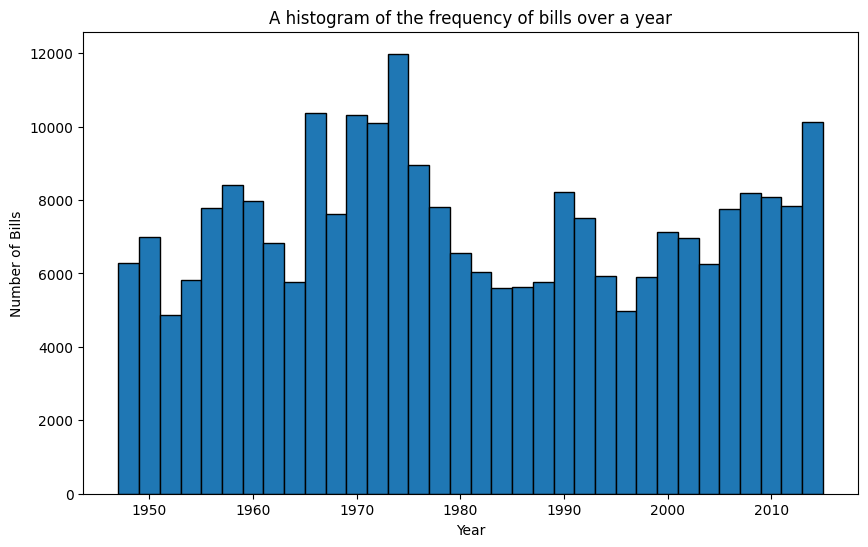

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
bills = pd.read_csv(os.path.join(repo_dir, "01_bills/bills.csv"), low_memory=False)
print(f"Loaded bills data, n = {len(bills)}")

plt.figure(figsize=(10, 6))
bills['Year'].hist(bins=range(int(bills['Year'].min()), int(bills['Year'].max()) + 1, 2), edgecolor='black')
plt.title('A histogram of the frequency of bills over a year')
plt.xlabel('Year')
plt.ylabel('Number of Bills')
plt.grid(False)
plt.show()